<a href="https://colab.research.google.com/github/keerthanarbsc24-debug/Deep_learning/blob/main/Chest%20X-ray%20Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
!pip install -q kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ghost5612/chest-x-ray-images-normal-and-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-x-ray-images-normal-and-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-x-ray-images-normal-and-pneumonia


In [ ]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/ghost5612/chest-x-ray-images-normal-and-pneumonia/versions/1"

for root, dirs, files in os.walk(dataset_path):
    if "train" in dirs or "test" in dirs:
        print(root)

/root/.cache/kagglehub/datasets/ghost5612/chest-x-ray-images-normal-and-pneumonia/versions/1/chest_xray


In [ ]:
train_dir = dataset_path + "/chest_xray/train"
test_dir = dataset_path + "/chest_xray/test"

print(train_dir)
print(test_dir)

/root/.cache/kagglehub/datasets/ghost5612/chest-x-ray-images-normal-and-pneumonia/versions/1/chest_xray/train
/root/.cache/kagglehub/datasets/ghost5612/chest-x-ray-images-normal-and-pneumonia/versions/1/chest_xray/test


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 5

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.


In [ ]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 5216 files belonging to 2 classes.
Using 1043 files for validation.


In [ ]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 624 files belonging to 2 classes.


In [ ]:
print("Classes:", train_dataset.class_names)

Classes: ['NORMAL', 'PNEUMONIA']


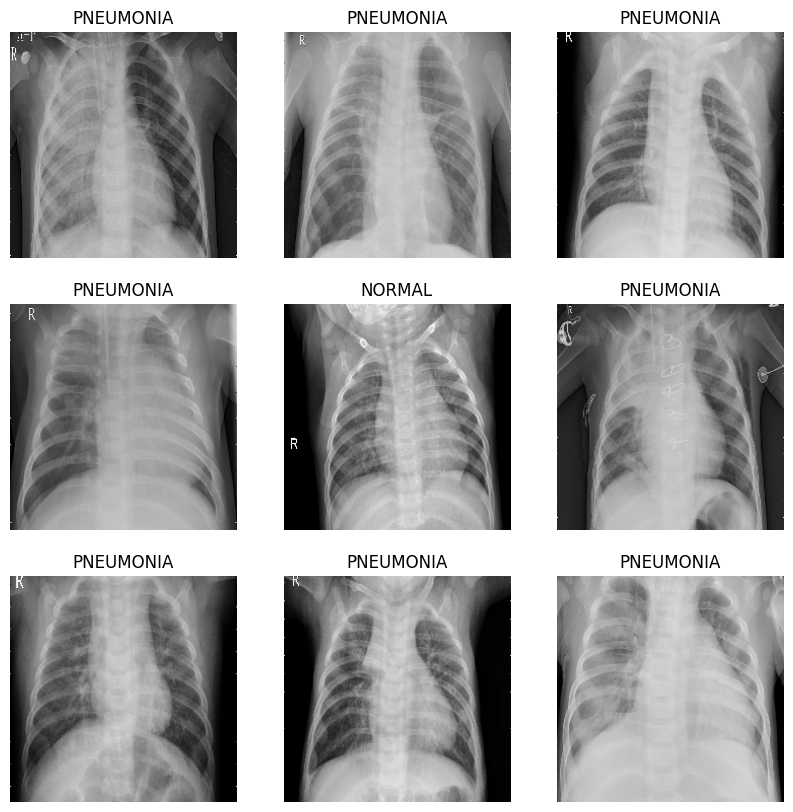

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8"),
            cmap="gray"
        )

        plt.title(
            train_dataset.class_names[int(labels[i])]
        )

        plt.axis("off")

plt.show()

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
inputs = layers.Input(shape=(224, 224, 3))

x = preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation="relu")(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

Epoch 1/5
261/261 ━━━━━━━━━━━━━━━━━━━━ 905s 3s/step - accuracy: 0.9300 - loss: 0.1883 - val_accuracy: 0.9597 - val_loss: 0.0899
Epoch 2/5
261/261 ━━━━━━━━━━━━━━━━━━━━ 881s 3s/step - accuracy: 0.9569 - loss: 0.1091 - val_accuracy: 0.9645 - val_loss: 0.0757
Epoch 3/5
261/261 ━━━━━━━━━━━━━━━━━━━━ 870s 3s/step - accuracy: 0.9609 - loss: 0.1000 - val_accuracy: 0.9770 - val_loss: 0.0640
Epoch 4/5
261/261 ━━━━━━━━━━━━━━━━━━━━ 943s 3s/step - accuracy: 0.9674 - loss: 0.0880 - val_accuracy: 0.9799 - val_loss: 0.0493
Epoch 5/5
261/261 ━━━━━━━━━━━━━━━━━━━━ 885s 3s/step - accuracy: 0.9700 - loss: 0.0742 - val_accuracy: 0.9751 - val_loss: 0.0632


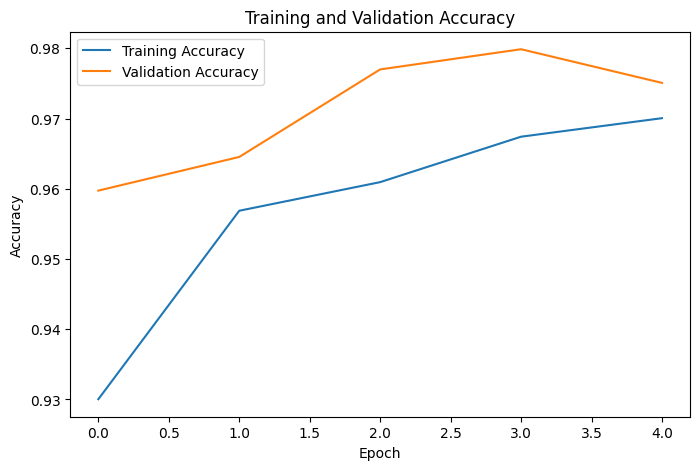

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()

plt.show()

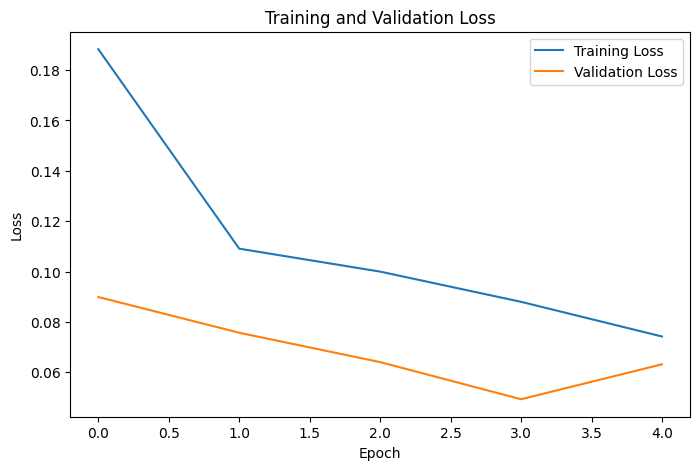

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(
    test_dataset
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

39/39 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.8317 - loss: 0.5389
Test Loss: 0.538925051689148
Test Accuracy: 0.8317307829856873


In [ ]:
for images, labels in test_dataset.take(1):

    predictions = model.predict(images)

    for i in range(5):

        if predictions[i][0] > 0.5:
            predicted_class = "PNEUMONIA"
        else:
            predicted_class = "NORMAL"

        actual_class = test_dataset.class_names[
            int(labels[i])
        ]

        print("Actual:", actual_class)
        print("Predicted:", predicted_class)
        print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Actual: NORMAL
Predicted: NORMAL

Actual: NORMAL
Predicted: NORMAL

Actual: NORMAL
Predicted: NORMAL

Actual: NORMAL
Predicted: NORMAL

Actual: NORMAL
Predicted: NORMAL



1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


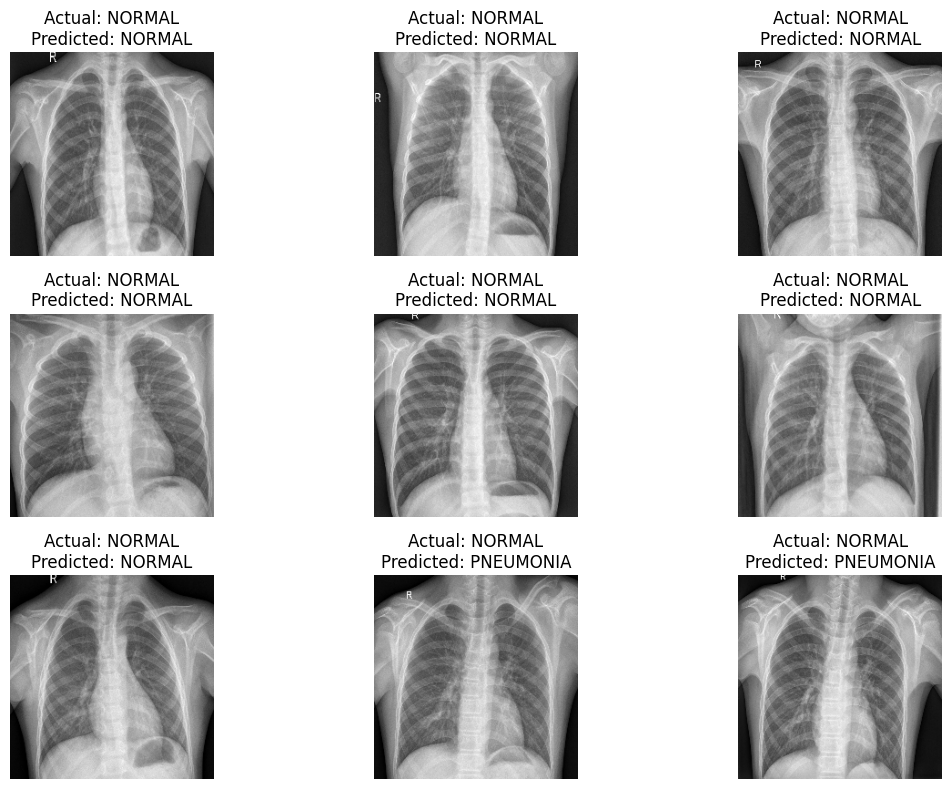

In [ ]:
plt.figure(figsize=(12, 8))

for images, labels in test_dataset.take(1):

    predictions = model.predict(images)

    for i in range(9):

        if predictions[i][0] > 0.5:
            predicted_class = "PNEUMONIA"
        else:
            predicted_class = "NORMAL"

        actual_class = test_dataset.class_names[int(labels[i])]

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8"),
            cmap="gray"
        )

        plt.title(
            "Actual: " + actual_class +
            "\nPredicted: " + predicted_class
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model.save("/content/resnet50_chest_xray.keras")

print("Model saved successfully!")

Model saved successfully!
